<a href="https://colab.research.google.com/github/teodoraztodorovic/TiAuMU/blob/main/TiAuMU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predviđanje ponovne hospitalizacije dijabetičkih pacijenata u roku od 30 dana


In [1]:
!pip install -q ray[tune] imbalanced-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 11.5 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score,
    f1_score, balanced_accuracy_score, brier_score_loss, confusion_matrix,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

##Učitavanje i pregled podataka


In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/MLOps'
df = pd.read_csv(f'{DATA_DIR}/diabetic_data.csv')
ids_mapping = pd.read_csv(f'{DATA_DIR}/IDS_mapping.csv')
print(df.shape)
df.head()

Mounted at /content/drive
(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
question_mark_counts = (df == '?').sum()
question_mark_counts = question_mark_counts[question_mark_counts > 0].sort_values(ascending=False)
real_nan_counts = df.isna().sum()
real_nan_counts = real_nan_counts[real_nan_counts > 0].sort_values(ascending=False)
print('Kolone sa "?" oznakom nedostajuće vrednosti:')
print(question_mark_counts)
print('\nKolone sa pravim NaN vrednostima:')
print(real_nan_counts)
id_like_cols = [c for c in df.columns if 'id' in c.lower()]
print('\nID-nalik kolone:', id_like_cols)

Kolone sa "?" oznakom nedostajuće vrednosti:
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

Kolone sa pravim NaN vrednostima:
max_glu_serum    96420
A1Cresult        84748
dtype: int64

ID-nalik kolone: ['encounter_id', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'tolazamide', 'examide', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone']


In [5]:
display(ids_mapping)
print(df['discharge_disposition_id'].value_counts().sort_index())
print()
print(df['gender'].value_counts())
print()
print(df['race'].value_counts())

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


##EDA


In [6]:
df_eda = df.replace('?', np.nan)
expired_codes = [11, 19, 20]
df_eda = df_eda[~df_eda['discharge_disposition_id'].isin(expired_codes)].copy()
df_eda['target'] = (df_eda['readmitted'] == '<30').astype(int)
print(df_eda.shape)
df_eda['target'].value_counts(normalize=True)

(100114, 51)


,proportion
target,
0,0.886559
1,0.113441


In [7]:
overview = pd.DataFrame({
    'dtype': df_eda.dtypes,
    'n_unique': df_eda.nunique(),
    'n_missing': df_eda.isna().sum(),
    'pct_missing': (df_eda.isna().sum() / len(df_eda) * 100).round(2)
})
overview['cardinality_type'] = np.where(
    overview['n_unique'] <= 2, 'binary',
    np.where(overview['n_unique'] <= 20, 'low', 'high')
)
overview.sort_values('pct_missing', ascending=False)

,dtype,n_unique,n_missing,pct_missing,cardinality_type
weight,object,9,96958,96.85,low
max_glu_serum,object,3,94890,94.78,low
A1Cresult,object,3,83238,83.14,low
medical_specialty,object,72,49129,49.07,high
payer_code,object,17,39591,39.55,low
race,object,5,2239,2.24,low
diag_3,object,787,1421,1.42,high
diag_2,object,747,358,0.36,high
diag_1,object,715,21,0.02,high
patient_nbr,int64,70439,0,0.00,high


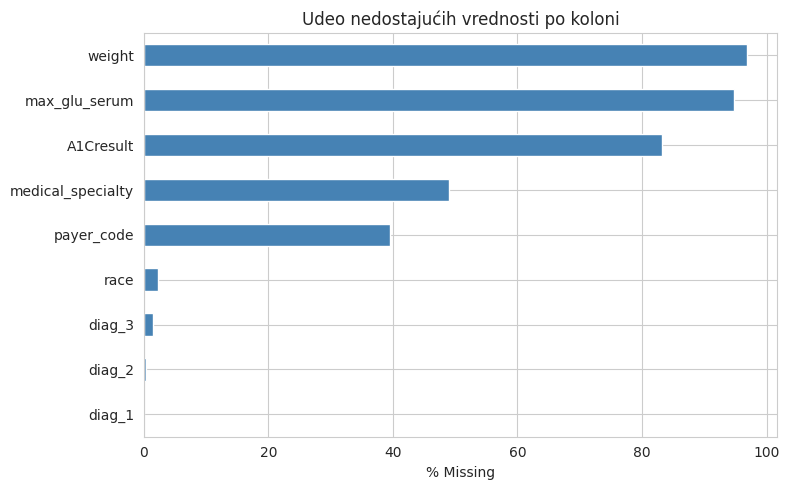

,n_missing,pct_missing
weight,96958,96.85
max_glu_serum,94890,94.78
A1Cresult,83238,83.14
medical_specialty,49129,49.07
payer_code,39591,39.55
race,2239,2.24
diag_3,1421,1.42
diag_2,358,0.36
diag_1,21,0.02


In [8]:
missing_report = overview[overview['n_missing'] > 0][['n_missing', 'pct_missing']]
missing_report = missing_report.sort_values('pct_missing', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
missing_report['pct_missing'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% Missing')
ax.set_title('Udeo nedostajućih vrednosti po koloni')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

missing_report

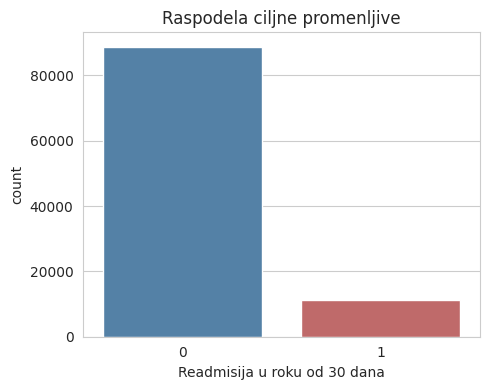

Odnos klasa (negativna : pozitivna): 7.82 : 1


In [9]:
target_counts = df_eda['target'].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='target', data=df_eda, ax=ax, palette=['steelblue', 'indianred'])
ax.set_title('Raspodela ciljne promenljive')
ax.set_xlabel('Readmisija u roku od 30 dana')
plt.tight_layout()
plt.show()

print(f'Odnos klasa (negativna : pozitivna): {target_counts[0]/target_counts[1]:.2f} : 1')

In [10]:
exclude_from_numeric = ['encounter_id', 'patient_nbr', 'admission_type_id','discharge_disposition_id', 'admission_source_id', 'target']
numeric_cols = [c for c in df_eda.select_dtypes(include=[np.number]).columns
                if c not in exclude_from_numeric]

numeric_summary = df_eda[numeric_cols].describe().T
numeric_summary['skew'] = df_eda[numeric_cols].skew()
display(numeric_summary)
for col in numeric_cols:
    q1, q3 = df_eda[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_eda[col] < lower) | (df_eda[col] > upper)).sum()
    print(f'{col}: {n_outliers} outliera ({n_outliers/len(df_eda)*100:.2f}%)')

,count,mean,std,min,25%,50%,75%,max,skew
time_in_hospital,100114.0,4.389646,2.974531,1.0,2.0,4.0,6.0,14.0,1.137881
num_lab_procedures,100114.0,42.943305,19.620940,1.0,31.0,44.0,57.0,132.0,-0.241460
num_procedures,100114.0,1.330723,1.700286,0.0,0.0,1.0,2.0,6.0,1.326129
num_medications,100114.0,15.981821,8.092511,1.0,10.0,15.0,20.0,81.0,1.333118
number_outpatient,100114.0,0.369429,1.264006,0.0,0.0,0.0,0.0,42.0,8.818131
number_emergency,100114.0,0.198334,0.935537,0.0,0.0,0.0,0.0,76.0,22.842144
number_inpatient,100114.0,0.632829,1.261833,0.0,0.0,0.0,1.0,21.0,3.626474
number_diagnoses,100114.0,7.409164,1.938288,1.0,6.0,8.0,9.0,16.0,-0.867589


time_in_hospital: 2186 outliera (2.18%)
num_lab_procedures: 122 outliera (0.12%)
num_procedures: 4811 outliera (4.81%)
num_medications: 2470 outliera (2.47%)
number_outpatient: 16490 outliera (16.47%)
number_emergency: 11189 outliera (11.18%)
number_inpatient: 6897 outliera (6.89%)
number_diagnoses: 278 outliera (0.28%)


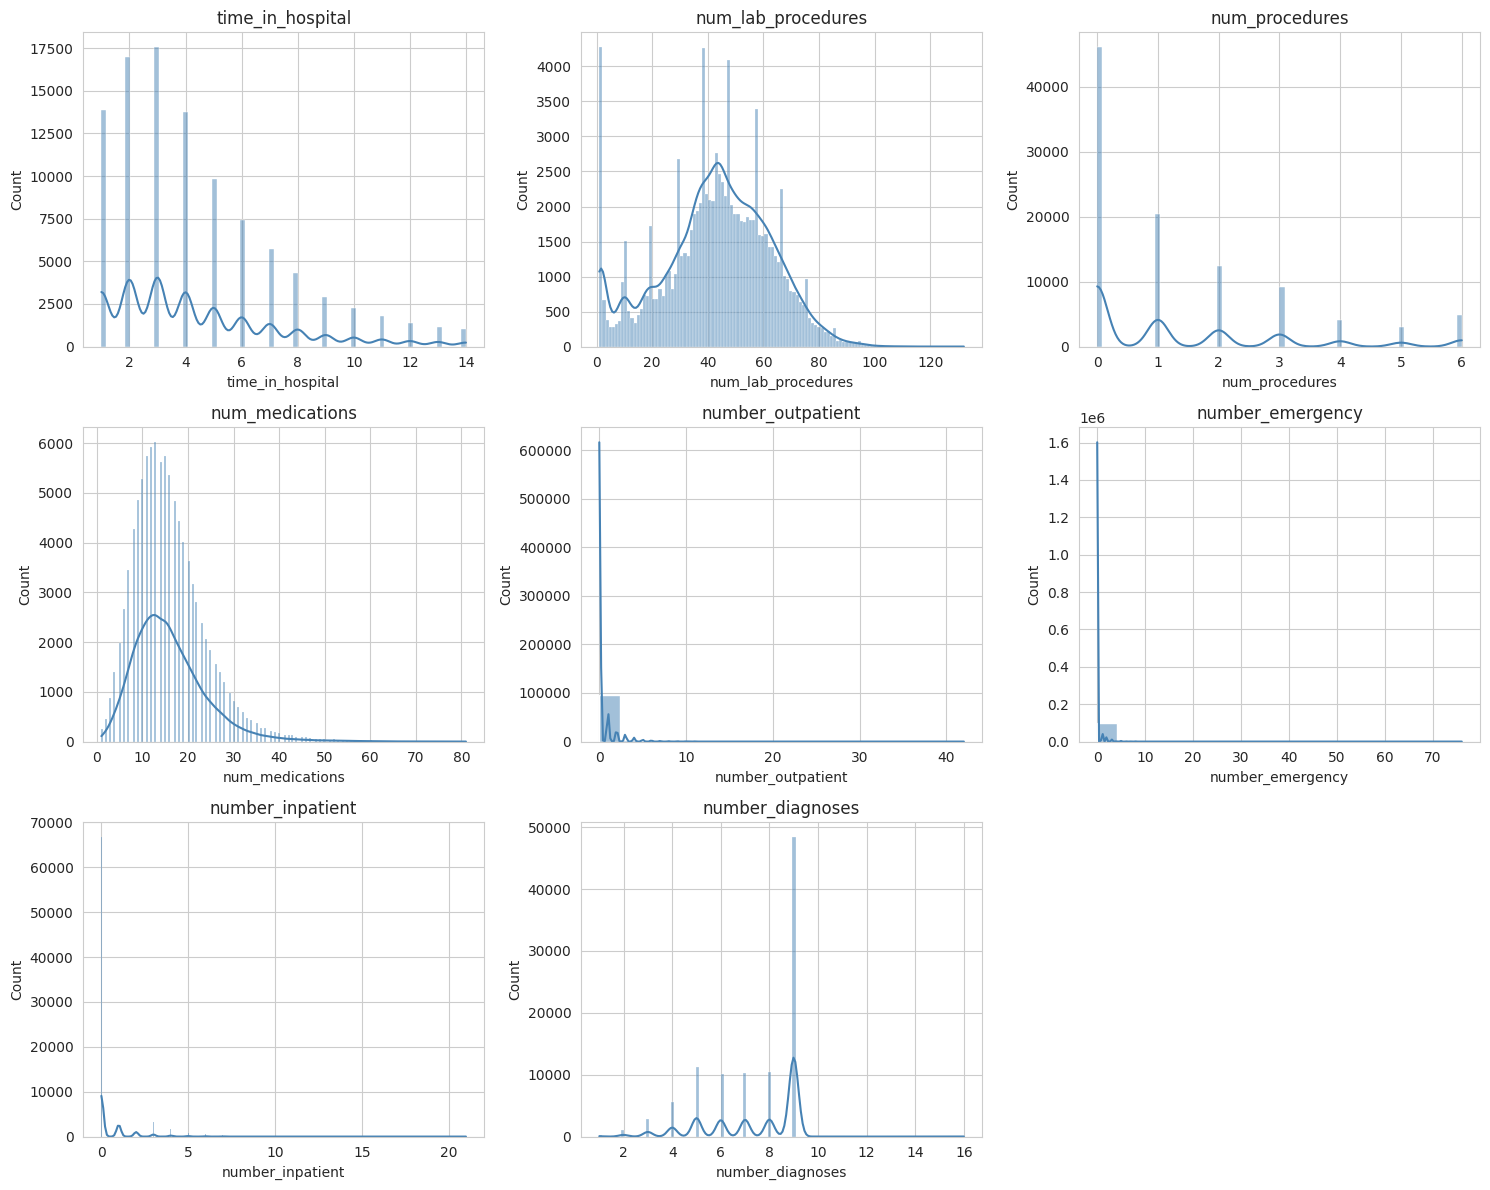

In [11]:
n_cols_plot = 3
n_rows_plot = int(np.ceil(len(numeric_cols) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, 4 * n_rows_plot))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_eda[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [12]:
exclude_from_cat = ['encounter_id', 'patient_nbr', 'readmitted']
categorical_cols = [c for c in df_eda.select_dtypes(include=['object']).columns
                    if c not in exclude_from_cat]

cat_summary = []
for col in categorical_cols:
    vc = df_eda[col].value_counts(dropna=False)
    cat_summary.append({
        'column': col,
        'n_categories': df_eda[col].nunique(dropna=True),
        'top_category': vc.index[0],
        'top_category_pct': round(vc.iloc[0] / len(df_eda) * 100, 2)
    })
cat_summary_df = pd.DataFrame(cat_summary).sort_values('n_categories', ascending=False)
cat_summary_df

,column,n_categories,top_category,top_category_pct
8,diag_3,787,250,11.48
7,diag_2,747,276,6.65
6,diag_1,715,428,6.73
5,medical_specialty,72,NaN,49.07
4,payer_code,17,NaN,39.55
2,age,10,[70-80),25.53
3,weight,9,NaN,96.85
0,race,5,Caucasian,74.76
29,glyburide-metformin,4,No,99.30
11,metformin,4,No,80.12


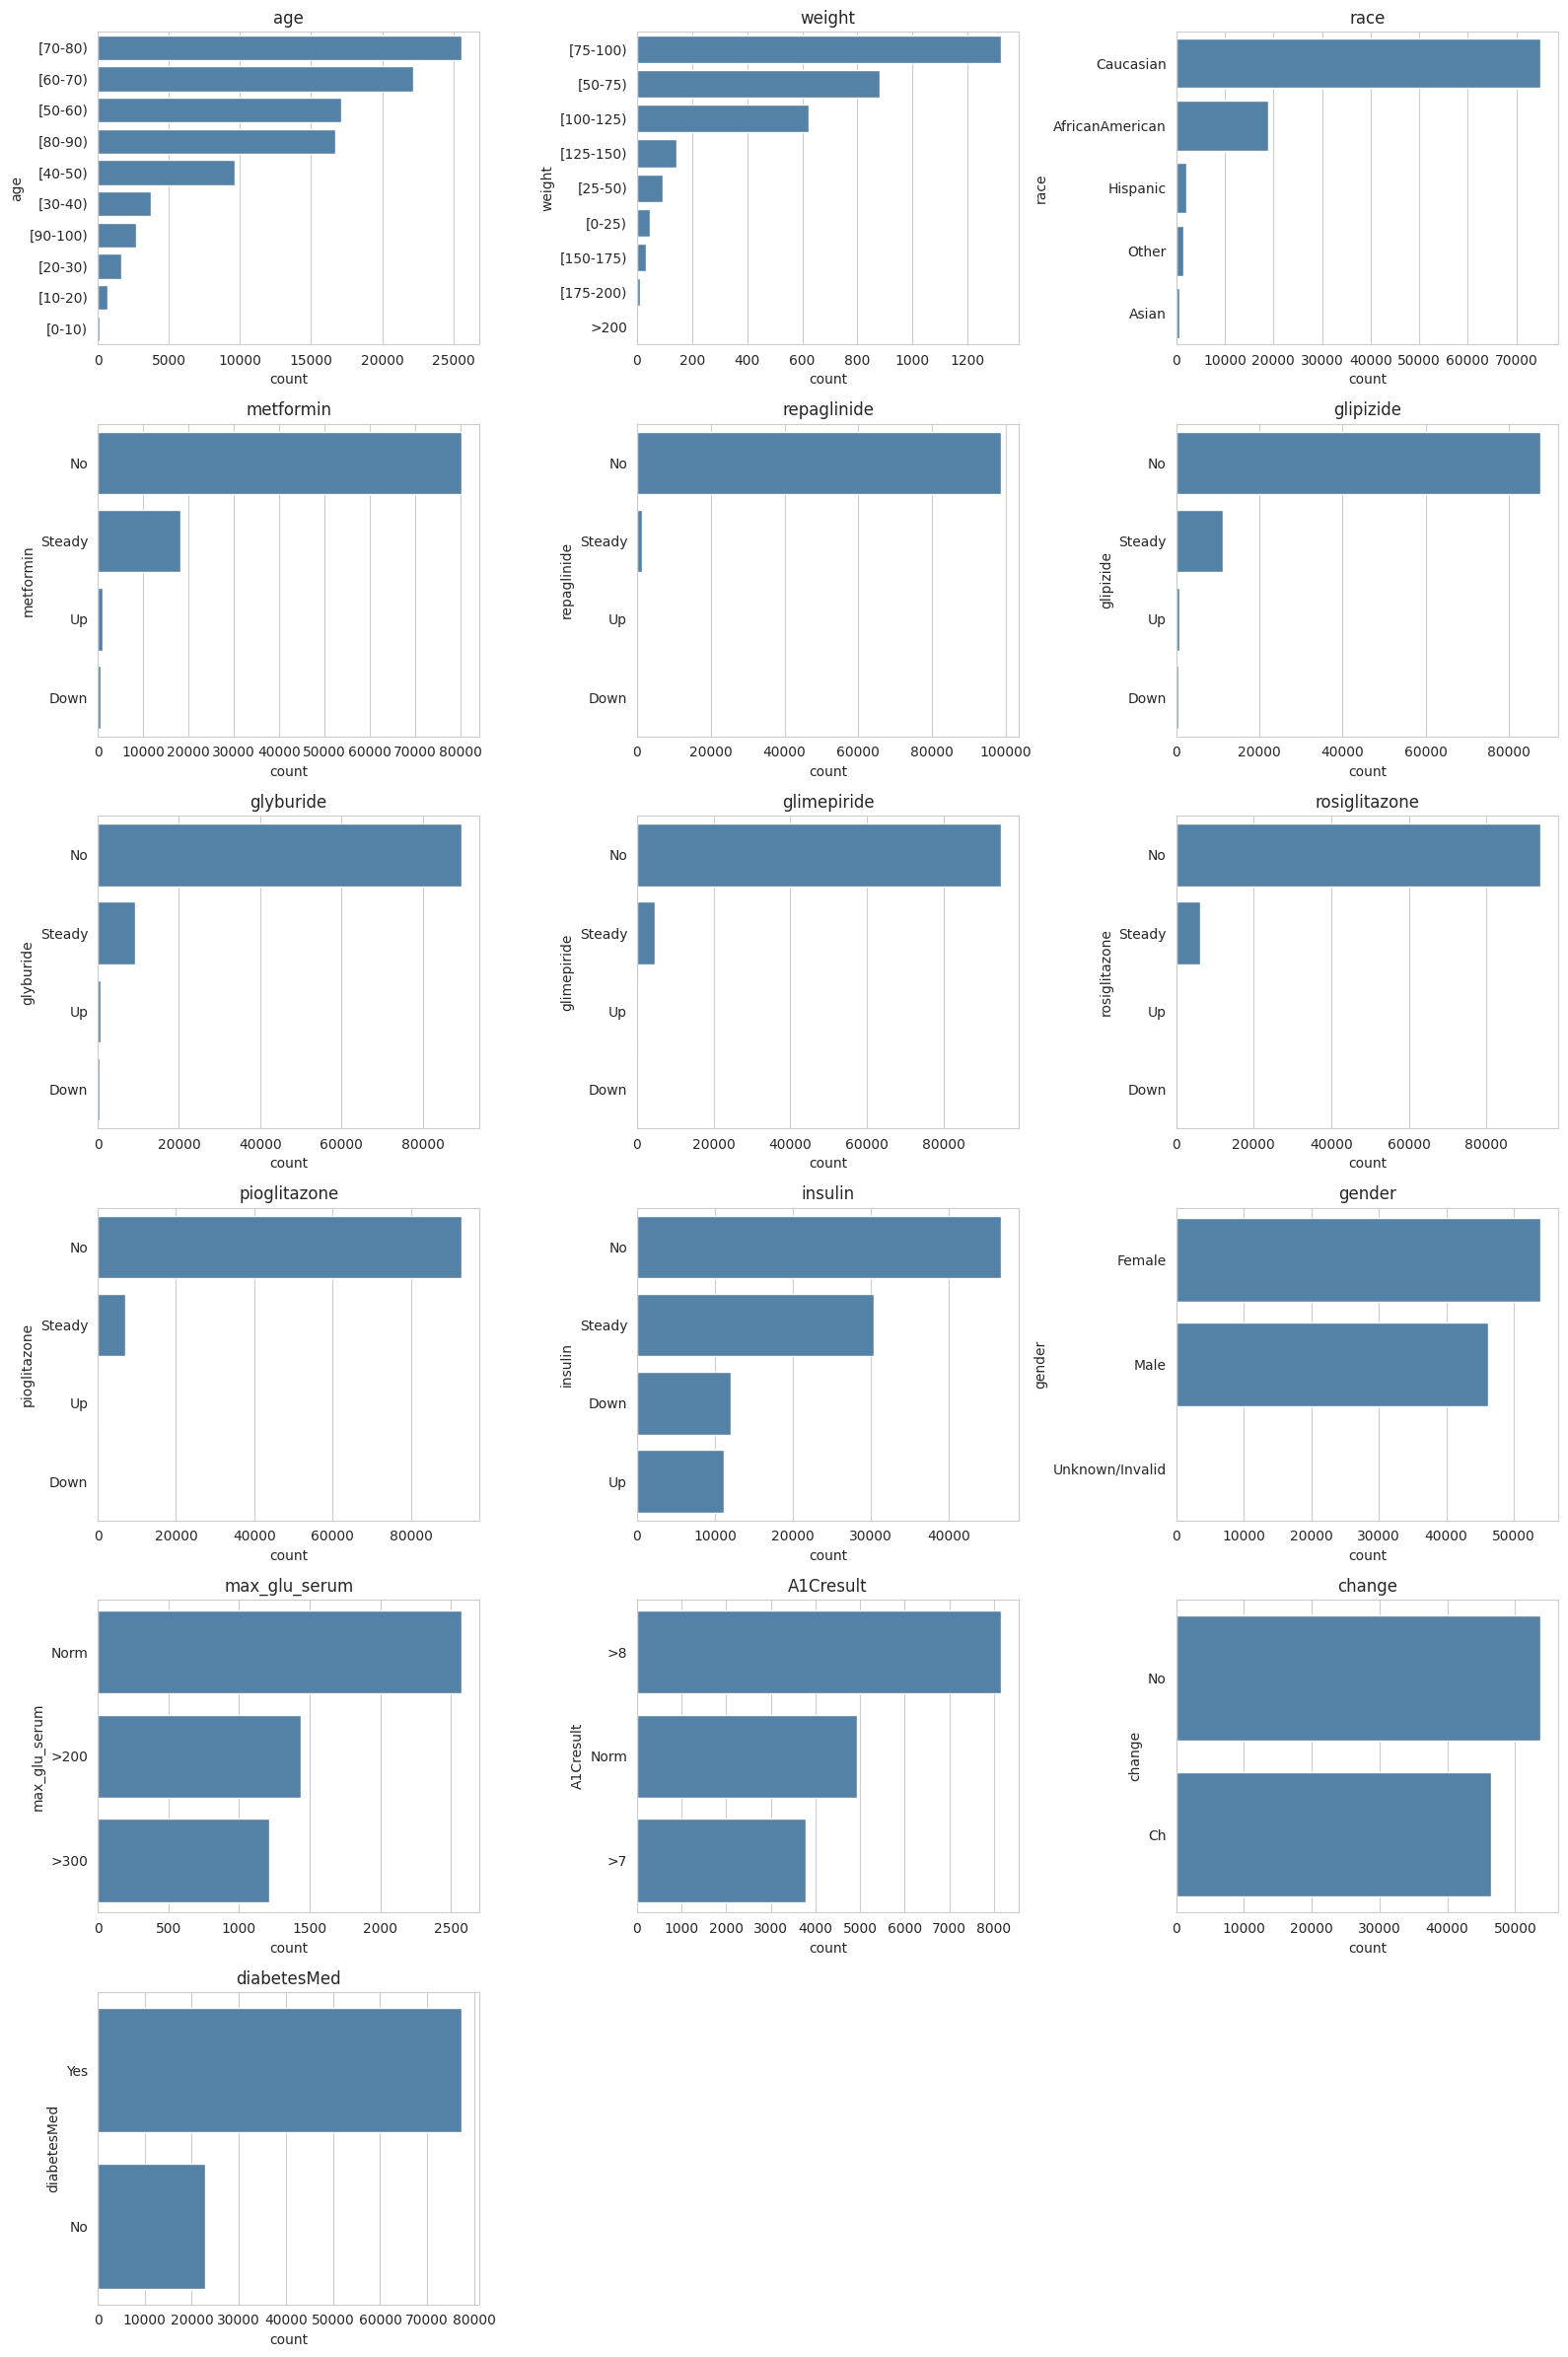

In [13]:
plot_worthy_cats = cat_summary_df[
    (cat_summary_df['top_category_pct'] < 99) &
    (cat_summary_df['n_categories'] <= 15)
]['column'].tolist()

n_cols_plot = 3
n_rows_plot = int(np.ceil(len(plot_worthy_cats) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 4 * n_rows_plot))
axes = axes.flatten()
for i, col in enumerate(plot_worthy_cats):
    order = df_eda[col].value_counts().index[:10]
    sns.countplot(y=col, data=df_eda, order=order, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

,target_0_mean,target_1_mean,diff
num_lab_procedures,42.779172,44.226028,1.446856
num_medications,15.863932,16.903143,1.039212
number_inpatient,0.557184,1.224003,0.666819
time_in_hospital,4.341201,4.768249,0.427047
number_diagnoses,7.372872,7.692789,0.319917
number_emergency,0.177992,0.357313,0.179321
number_outpatient,0.360794,0.436911,0.076117
num_procedures,1.337100,1.280884,-0.056216


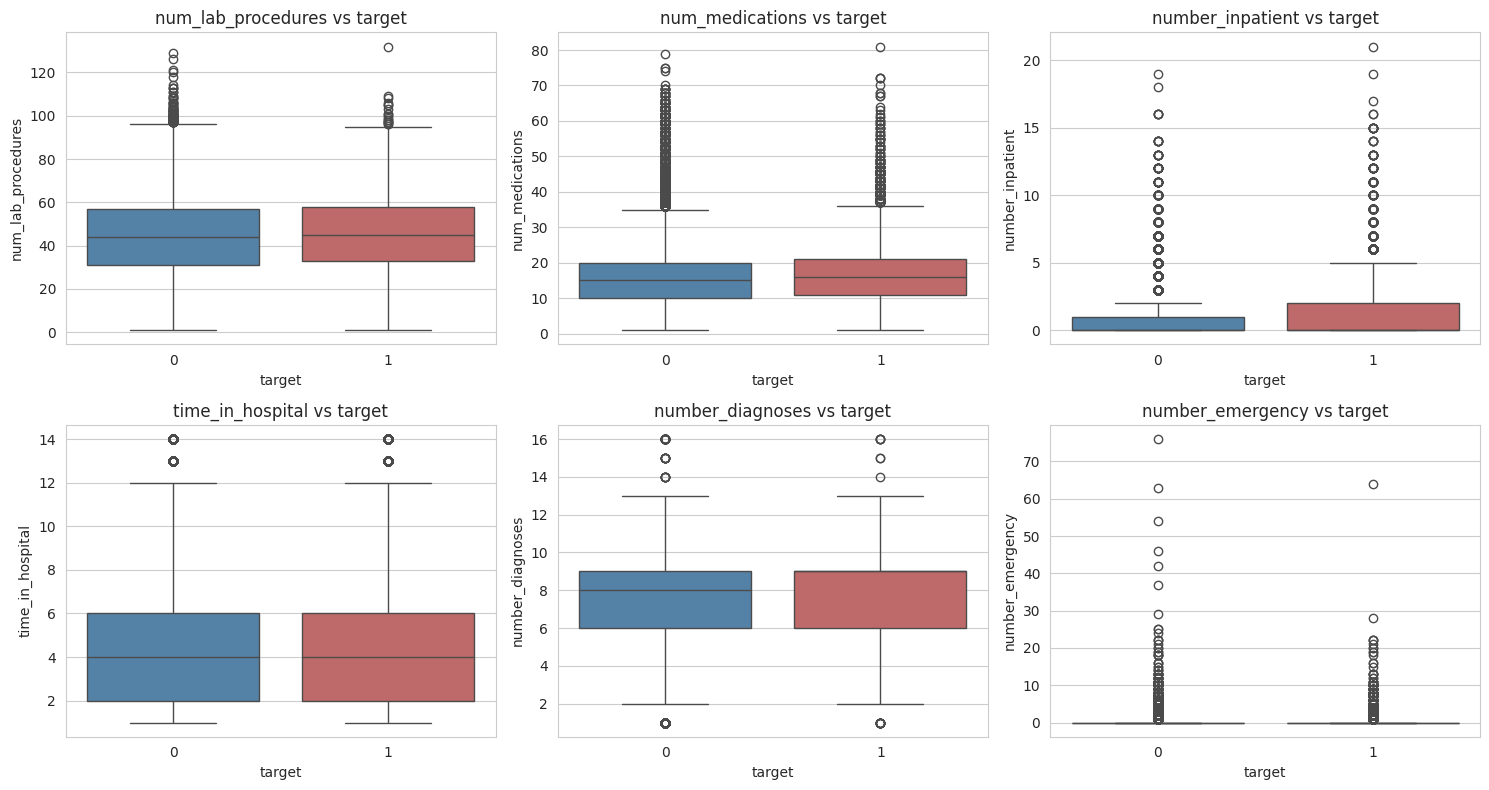

In [14]:
target_relation = df_eda.groupby('target')[numeric_cols].mean().T
target_relation.columns = ['target_0_mean', 'target_1_mean']
target_relation['diff'] = target_relation['target_1_mean'] - target_relation['target_0_mean']
display(target_relation.sort_values('diff', key=abs, ascending=False))

top_features_by_diff = target_relation.sort_values('diff', key=abs, ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(top_features_by_diff):
    sns.boxplot(x='target', y=col, data=df_eda, ax=axes[i], palette=['steelblue', 'indianred'])
    axes[i].set_title(f'{col} vs target')
plt.tight_layout()
plt.show()

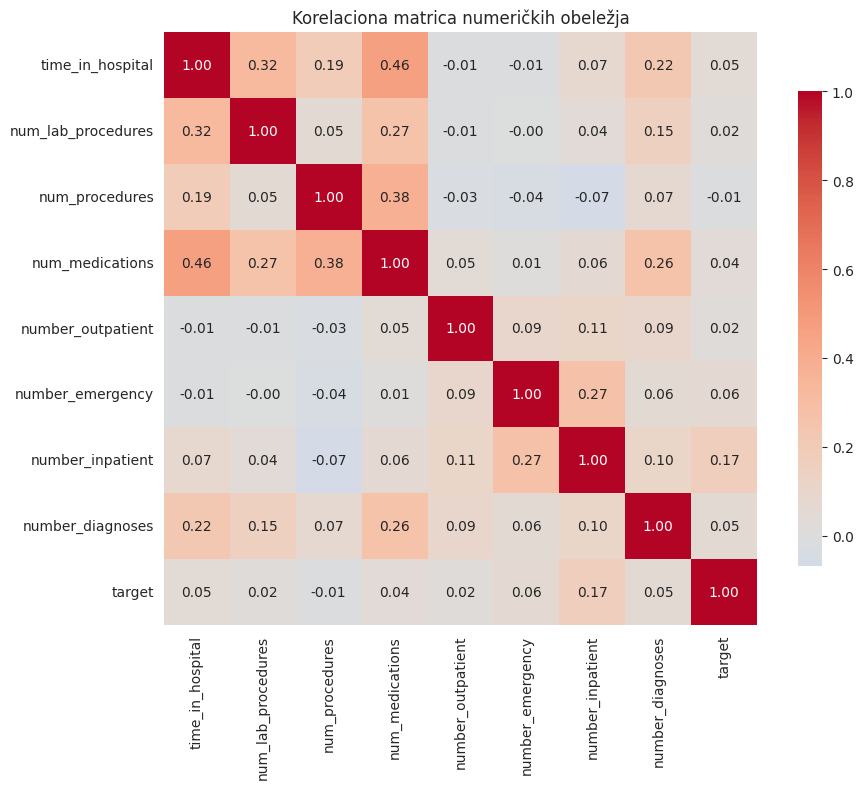

,target
number_inpatient,0.167589
number_emergency,0.060787
number_diagnoses,0.052343
time_in_hospital,0.045530
num_medications,0.040725
num_lab_procedures,0.023385
number_outpatient,0.019097
num_procedures,-0.010485


In [15]:
corr_cols = numeric_cols + ['target']
corr_matrix = df_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Korelaciona matrica numeričkih obeležja')
plt.tight_layout()
plt.show()

corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)

##Nedostajuće vrednosti (MCAR / MAR / MNAR)

In [16]:
missing_cols = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code', 'race', 'diag_3', 'diag_2', 'diag_1']

df_miss = df_eda.copy()
for col in missing_cols:
    df_miss[f'{col}_missing'] = df_miss[col].isna().astype(int)

indicator_cols = [f'{c}_missing' for c in missing_cols]

(df_miss[indicator_cols].mean() * 100).round(2)

,0
weight_missing,96.85
max_glu_serum_missing,94.78
A1Cresult_missing,83.14
medical_specialty_missing,49.07
payer_code_missing,39.55
race_missing,2.24
diag_3_missing,1.42
diag_2_missing,0.36
diag_1_missing,0.02


In [17]:
target_assoc_results = []
for col in missing_cols:
    ind = f'{col}_missing'
    contingency = pd.crosstab(df_miss[ind], df_miss['target'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    cramers_v = np.sqrt(chi2 / n)
    target_assoc_results.append({'feature': col, 'chi2': chi2, 'p_value': p, 'cramers_v': cramers_v, 'n': n})

target_assoc_df = pd.DataFrame(target_assoc_results).sort_values('cramers_v', ascending=False)
target_assoc_df

,feature,chi2,p_value,cramers_v,n
2,A1Cresult,40.114996,2.394438e-10,0.020017,100114
6,diag_3,34.482075,4.301948e-09,0.018559,100114
5,race,19.484581,1.014150e-05,0.013951,100114
3,medical_specialty,17.073521,3.596020e-05,0.013059,100114
1,max_glu_serum,9.254517,2.349153e-03,0.009615,100114
4,payer_code,7.601602,5.831647e-03,0.008714,100114
7,diag_2,3.441613,6.357359e-02,0.005863,100114
8,diag_1,2.123943,1.450128e-01,0.004606,100114
0,weight,0.000876,9.763948e-01,0.000094,100114


In [18]:
numeric_cols_for_test = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

mw_results = []
for col in missing_cols:
    ind = f'{col}_missing'
    group_missing = df_miss.loc[df_miss[ind] == 1]
    group_present = df_miss.loc[df_miss[ind] == 0]
    for num_col in numeric_cols_for_test:
        u_stat, p = stats.mannwhitneyu(group_missing[num_col], group_present[num_col], alternative='two-sided')
        n1, n2 = len(group_missing), len(group_present)
        rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
        mw_results.append({
            'missing_indicator': col, 'numeric_feature': num_col,
            'p_value': p, 'rank_biserial_r': rank_biserial,
            'median_missing': group_missing[num_col].median(),
            'median_present': group_present[num_col].median()
        })

mw_df = pd.DataFrame(mw_results)
mw_df['abs_effect'] = mw_df['rank_biserial_r'].abs()
mw_df.sort_values('abs_effect', ascending=False)

,missing_indicator,numeric_feature,p_value,rank_biserial_r,median_missing,median_present,abs_effect
55,diag_3,number_diagnoses,0.000000e+00,0.955498,2.0,8.0,0.955498
63,diag_2,number_diagnoses,2.836901e-184,0.831296,1.0,8.0,0.831296
59,diag_2,num_medications,2.457164e-87,0.604967,7.0,15.0,0.604967
51,diag_3,num_medications,5.186403e-263,0.533918,8.0,15.0,0.533918
9,max_glu_serum,num_lab_procedures,0.000000e+00,-0.446022,45.0,23.0,0.446022
...,...,...,...,...,...,...,...
30,medical_specialty,number_inpatient,5.857496e-04,-0.010478,0.0,0.0,0.010478
29,medical_specialty,number_emergency,8.777230e-06,-0.008869,0.0,0.0,0.008869
24,medical_specialty,time_in_hospital,1.975357e-02,-0.008435,4.0,4.0,0.008435
64,diag_1,time_in_hospital,9.878603e-01,0.001901,4.0,4.0,0.001901


In [19]:
categorical_for_test = ['age', 'gender', 'admission_type_id', 'admission_source_id','discharge_disposition_id', 'diabetesMed', 'change', 'insulin']

cat_assoc_results = []
for col in missing_cols:
    ind = f'{col}_missing'
    for cat_col in categorical_for_test:
        if cat_col == col:
            continue
        contingency = pd.crosstab(df_miss[ind], df_miss[cat_col])
        try:
            chi2, p, dof, expected = stats.chi2_contingency(contingency)
            n = contingency.sum().sum()
            cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
            cat_assoc_results.append({
                'missing_indicator': col, 'categorical_feature': cat_col,
                'chi2': chi2, 'p_value': p, 'cramers_v': cramers_v
            })
        except ValueError:
            continue

cat_assoc_df = pd.DataFrame(cat_assoc_results)
cat_assoc_df.sort_values('cramers_v', ascending=False)

,missing_indicator,categorical_feature,chi2,p_value,cramers_v
11,max_glu_serum,admission_source_id,38657.790042,0.000000,0.621400
10,max_glu_serum,admission_type_id,34261.630977,0.000000,0.585001
48,diag_3,age,9717.836477,0.000000,0.311557
26,medical_specialty,admission_type_id,9158.666565,0.000000,0.302461
34,payer_code,admission_type_id,9053.411888,0.000000,0.300718
...,...,...,...,...,...
71,diag_1,insulin,1.382448,0.709654,0.003716
62,diag_2,change,1.033776,0.309274,0.003213
9,max_glu_serum,gender,0.649774,0.722609,0.002548
70,diag_1,change,0.295387,0.586789,0.001718


In [20]:
def run_missingness_logit(indicator_col, data, numeric_predictors, categorical_predictors, exclude_col=None):
    predictors = [c for c in categorical_predictors if c != exclude_col]
    X_num = data[numeric_predictors].copy()
    X_cat = pd.get_dummies(data[predictors].astype(str), drop_first=True)
    X = pd.concat([X_num, X_cat], axis=1).astype(float)
    X = sm.add_constant(X)
    y = data[indicator_col].astype(float)
    model = sm.Logit(y, X)
    try:
        return model.fit(disp=0, maxiter=200)
    except Exception as e:
        print(f'Model za {indicator_col} nije konvergirao: {e}')
        return None

categorical_predictors = ['age', 'gender', 'admission_type_id', 'admission_source_id']
logit_results_summary = []

for col in missing_cols:
    ind = f'{col}_missing'
    exclude = col if col in categorical_predictors else None
    result = run_missingness_logit(ind, df_miss, numeric_cols_for_test, categorical_predictors, exclude_col=exclude)
    if result is not None:
        print(f'\n {ind} ~ observed features | Pseudo R2: {result.prsquared:.4f}')
        coefs = result.summary2().tables[1].copy()
        coefs['abs_z'] = coefs['z'].abs()
        display(coefs.sort_values('abs_z', ascending=False).head(8))
        logit_results_summary.append({'indicator': ind, 'pseudo_r2': result.prsquared})

pd.DataFrame(logit_results_summary).sort_values('pseudo_r2', ascending=False)

/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(



 weight_missing ~ observed features | Pseudo R2: 0.1296


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],abs_z
num_lab_procedures,-0.032920,0.001184,-27.796597,4.768619e-170,-0.035241,-0.030599,27.796597
number_outpatient,-0.228758,0.008751,-26.139944,1.282386e-150,-0.245910,-0.211606,26.139944
number_diagnoses,-0.198800,0.012753,-15.588464,8.720457e-55,-0.223796,-0.173805,15.588464
admission_source_id_5,-1.654102,0.108761,-15.208576,3.102161e-52,-1.867270,-1.440934,15.208576
admission_source_id_7,0.946095,0.070798,13.363272,9.910973e-41,0.807333,1.084857,13.363272
num_medications,0.036856,0.002983,12.357326,4.447068e-35,0.031010,0.042702,12.357326
const,4.797995,0.470774,10.191727,2.158940e-24,3.875296,5.720694,10.191727
admission_type_id_5,4.817731,0.624950,7.708992,1.268154e-14,3.592852,6.042609,7.708992


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(



 max_glu_serum_missing ~ observed features | Pseudo R2: 0.5839


...

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],abs_z
number_diagnoses,-1.110299,0.050709,-21.895369,2.875691e-106,-1.209687,-1.010910,21.895369
age_[50-60),-2.324117,0.309591,-7.507046,6.047642e-14,-2.930905,-1.717329,7.507046
age_[30-40),-2.119070,0.329354,-6.434029,1.242652e-10,-2.764592,-1.473549,6.434029
age_[40-50),-1.779981,0.281359,-6.326374,2.509892e-10,-2.331435,-1.228528,6.326374
age_[70-80),-1.758089,0.292705,-6.006344,1.897539e-09,-2.331780,-1.184397,6.006344
age_[60-70),-1.663708,0.286958,-5.797743,6.721325e-09,-2.226135,-1.101281,5.797743
const,1.841420,0.350710,5.250544,1.516506e-07,1.154040,2.528800,5.250544
admission_source_id_6,1.311425,0.295716,4.434752,9.217830e-06,0.731833,1.891017,4.434752


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(



 diag_1_missing ~ observed features | Pseudo R2: 0.1064


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],abs_z
admission_source_id_7,-1.980476,0.718200,-2.757555,0.005824,-3.388121,-0.572830,2.757555
gender_Male,1.408417,0.519086,2.713265,0.006662,0.391028,2.425806,2.713265
num_procedures,-0.477293,0.232282,-2.054797,0.039899,-0.932557,-0.022028,2.054797
admission_type_id_2,-1.861474,0.915815,-2.032587,0.042094,-3.656438,-0.066509,2.032587
number_inpatient,0.155011,0.128726,1.204191,0.228516,-0.097288,0.407310,1.204191
admission_type_id_3,-0.863191,0.751803,-1.148161,0.250902,-2.336697,0.610316,1.148161
num_lab_procedures,-0.012710,0.012630,-1.006333,0.314255,-0.037464,0.012044,1.006333
number_outpatient,-0.409378,0.439949,-0.930513,0.352106,-1.271663,0.452906,0.930513


,indicator,pseudo_r2
6,diag_3_missing,0.721248
1,max_glu_serum_missing,0.583919
7,diag_2_missing,0.444423
4,payer_code_missing,0.176128
0,weight_missing,0.129583
3,medical_specialty_missing,0.127169
2,A1Cresult_missing,0.116772
8,diag_1_missing,0.106352
5,race_missing,0.087191


In [21]:
df_clean = df_eda.drop(columns=indicator_cols, errors='ignore').copy()
df_clean = df_clean.drop(columns=['weight'])
df_clean = df_clean[df_clean['diag_1'].notna()].copy()
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid'].copy()

for col in ['max_glu_serum', 'A1Cresult']:
    df_clean[col] = df_clean[col].fillna('Not_Tested')

for col in ['medical_specialty', 'payer_code', 'race']:
    df_clean[col] = df_clean[col].fillna('Unknown')

for col in ['diag_2', 'diag_3']:
    df_clean[col] = df_clean[col].fillna('Missing')

print(f'Finalni shape: {df_clean.shape}')
print(f'Preostalo nedostajućih vrednosti: {df_clean.isna().sum().sum()}')

Finalni shape: (100090, 50)
Preostalo nedostajućih vrednosti: 0


##Podela na trening i test skup na nivou pacijenta


In [22]:
n_patients = df_clean['patient_nbr'].nunique()
encounters_per_patient = df_clean['patient_nbr'].value_counts()

print(f'Encounters: {len(df_clean)}, unique pacijenata: {n_patients}')
print(f'Pacijenata sa vise od jednog encountera: {(encounters_per_patient > 1).mean()*100:.2f}%')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean['patient_nbr']))
df_train = df_clean.iloc[train_idx].copy()
df_test = df_clean.iloc[test_idx].copy()
overlap = set(df_train['patient_nbr']) & set(df_test['patient_nbr'])

print(f'\nTrain: {len(df_train)} redova, {df_train["patient_nbr"].nunique()} pacijenata')
print(f'Test:  {len(df_test)} redova, {df_test["patient_nbr"].nunique()} pacijenata')
print(f'Preklapanje pacijenata train/test: {len(overlap)}')

Encounters: 100090, unique pacijenata: 70427
Pacijenata sa vise od jednog encountera: 23.40%

Train: 80041 redova, 56341 pacijenata
Test:  20049 redova, 14086 pacijenata
Preklapanje pacijenata train/test: 0


##Bazni model(model pre FE)


In [23]:
exclude_cols = ['encounter_id', 'patient_nbr', 'readmitted', 'target']
feature_cols = [c for c in df_train.columns if c not in exclude_cols]

def prepare_xgb_features(data, cols):
    X = data[cols].copy()
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category')
    return X, cat_cols

X_train_base, cat_cols_base = prepare_xgb_features(df_train, feature_cols)
y_train_base = df_train['target'].values
groups_train_base = df_train['patient_nbr'].values

N_FOLDS = 5
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

def run_cv(X, y, groups, splitter, model_params, use_smote=False):
    fold_metrics = []
    for tr_idx, val_idx in splitter.split(X, y, groups=groups):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        if use_smote:
            X_tr_num = X_tr.apply(lambda s: s.cat.codes if str(s.dtype) == 'category' else s)
            X_tr_res, y_tr_res = SMOTE(random_state=RANDOM_SEED).fit_resample(X_tr_num, y_tr)
            X_tr = X_tr_res
            y_tr = y_tr_res
            X_val = X_val.apply(lambda s: s.cat.codes if str(s.dtype) == 'category' else s)

        n_neg, n_pos = (y_tr == 0).sum(), (y_tr == 1).sum()
        params = dict(model_params)
        params['scale_pos_weight'] = n_neg / n_pos

        model = xgb.XGBClassifier(**params, tree_method='hist', enable_categorical=True,
                                   eval_metric='aucpr', random_state=RANDOM_SEED, n_jobs=-1)
        model.fit(X_tr, y_tr)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        y_pred_label = (y_pred_proba >= 0.5).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred_label).ravel()
        fold_metrics.append({
            'roc_auc': roc_auc_score(y_val, y_pred_proba),
            'pr_auc': average_precision_score(y_val, y_pred_proba),
            'recall': recall_score(y_val, y_pred_label),
            'precision': precision_score(y_val, y_pred_label),
            'f1': f1_score(y_val, y_pred_label),
            'specificity': tn / (tn + fp),
            'balanced_accuracy': balanced_accuracy_score(y_val, y_pred_label),
            'brier_score': brier_score_loss(y_val, y_pred_proba),
        })
    return pd.DataFrame(fold_metrics)

base_params = dict(n_estimators=300, max_depth=6, learning_rate=0.05)

fold_df_baseline = run_cv(X_train_base, y_train_base, groups_train_base, sgkf, base_params)
summary_baseline = fold_df_baseline.agg(['mean', 'std']).T

summary_baseline

,mean,std
roc_auc,0.591586,0.003869
pr_auc,0.171786,0.005128
recall,0.324725,0.003619
precision,0.175501,0.006841
f1,0.227812,0.006362
specificity,0.804984,0.005174
balanced_accuracy,0.564854,0.003586
brier_score,0.171356,0.001246


##Inženjerstvo karakteristika


In [24]:
def map_age(age_str):
    lower, upper = age_str.strip('[)').split('-')
    return (int(lower) + int(upper)) / 2

def add_age_feature(data):
    data = data.copy()
    data['age_numeric'] = data['age'].apply(map_age)
    return data.drop(columns=['age'])

df_train_fe = add_age_feature(df_train)
df_test_fe = add_age_feature(df_test)

df_train_fe[['age_numeric']].describe()

,age_numeric
count,80041.000000
mean,65.818580
std,16.005749
min,5.000000
25%,55.000000
50%,65.000000
75%,75.000000
max,95.000000


In [25]:
medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide','glimepiride', 'acetohexamide', 'glipizide', 'glyburide','tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                    'miglitol', 'troglitazone', 'tolazamide', 'examide','citoglipton', 'insulin', 'glyburide-metformin',
                    'glipizide-metformin', 'glimepiride-pioglitazone',
                    'metformin-rosiglitazone', 'metformin-pioglitazone']

def icd9_to_category(code):
    if pd.isna(code) or code in ['Missing', 'Not_Tested']:
        return 'Missing'
    code = str(code)
    if code.startswith('V'):
        return 'Supplemental_V'
    if code.startswith('E'):
        return 'External_E'
    try:
        code_num = float(code)
    except ValueError:
        return 'Other'
    if 250 <= code_num < 251:
        return 'Diabetes'
    elif 390 <= code_num <= 459 or code_num == 785:
        return 'Circulatory'
    elif 460 <= code_num <= 519 or code_num == 786:
        return 'Respiratory'
    elif 520 <= code_num <= 579 or code_num == 787:
        return 'Digestive'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 580 <= code_num <= 629 or code_num == 788:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

def add_clinical_features(data):
    data = data.copy()
    data['total_prior_visits'] = data['number_outpatient'] + data['number_emergency'] + data['number_inpatient']
    data['acute_prior_visits'] = data['number_emergency'] + data['number_inpatient']

    med_matrix = data[medication_cols]
    data['num_med_changes'] = (med_matrix.isin(['Up', 'Down'])).sum(axis=1)
    data['num_meds_prescribed'] = (med_matrix != 'No').sum(axis=1)

    data['labs_per_day'] = data['num_lab_procedures'] / data['time_in_hospital']
    data['meds_per_day'] = data['num_medications'] / data['time_in_hospital']
    data['procedures_per_day'] = data['num_procedures'] / data['time_in_hospital']

    data['diag_1_category'] = data['diag_1'].apply(icd9_to_category)
    data['diag_2_category'] = data['diag_2'].apply(icd9_to_category)
    data['diag_3_category'] = data['diag_3'].apply(icd9_to_category)
    return data

df_train_fe = add_clinical_features(df_train_fe)
df_test_fe = add_clinical_features(df_test_fe)

df_train_fe[['total_prior_visits', 'acute_prior_visits', 'num_med_changes',
             'num_meds_prescribed', 'labs_per_day', 'meds_per_day', 'procedures_per_day']].describe()

,total_prior_visits,acute_prior_visits,num_med_changes,num_meds_prescribed,labs_per_day,meds_per_day,procedures_per_day
count,80041.000000,80041.000000,80041.000000,80041.000000,80041.000000,80041.000000,80041.000000
mean,1.197037,0.827301,0.287852,1.188478,14.294283,5.057881,0.448693
std,2.277296,1.753307,0.487498,0.924800,11.925772,3.806503,0.866453
min,0.000000,0.000000,0.000000,0.000000,0.071429,0.083333,0.000000
25%,0.000000,0.000000,0.000000,1.000000,6.500000,2.600000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,10.833333,4.000000,0.142857
75%,2.000000,1.000000,1.000000,2.000000,18.333333,6.000000,0.500000
max,80.000000,78.000000,4.000000,6.000000,92.000000,42.000000,6.000000


In [26]:
def add_cross_features(data):
    data = data.copy()
    data['age_x_number_inpatient'] = data['age_numeric'] * data['number_inpatient']
    data['time_in_hospital_x_num_medications'] = data['time_in_hospital'] * data['num_medications']
    data['num_procedures_x_num_lab_procedures'] = data['num_procedures'] * data['num_lab_procedures']
    data['total_prior_visits_x_num_diagnoses'] = data['total_prior_visits'] * data['number_diagnoses']
    return data

df_train_fe = add_cross_features(df_train_fe)
df_test_fe = add_cross_features(df_test_fe)

new_cross_cols = ['age_x_number_inpatient', 'time_in_hospital_x_num_medications',
                   'num_procedures_x_num_lab_procedures', 'total_prior_visits_x_num_diagnoses']
df_train_fe[new_cross_cols].describe()

,age_x_number_inpatient,time_in_hospital_x_num_medications,num_procedures_x_num_lab_procedures,total_prior_visits_x_num_diagnoses
count,80041.000000,80041.000000,80041.000000,80041.000000
mean,40.568459,81.341662,58.849565,9.425744
std,78.660952,89.015468,89.799675,18.900702
min,0.000000,1.000000,0.000000,0.000000
25%,0.000000,24.000000,0.000000,0.000000
50%,0.000000,51.000000,14.000000,0.000000
75%,65.000000,105.000000,84.000000,9.000000
max,975.000000,962.000000,726.000000,720.000000


In [27]:
feature_cols_fe = [c for c in df_train_fe.columns if c not in exclude_cols]

categorical_cols_fe = df_train_fe[feature_cols_fe].select_dtypes(include=['object']).columns.tolist()
numeric_cols_fe = [c for c in feature_cols_fe if c not in categorical_cols_fe]

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ordinal_encoder.fit(df_train_fe[categorical_cols_fe])

df_train_fe[categorical_cols_fe] = ordinal_encoder.transform(df_train_fe[categorical_cols_fe])
df_test_fe[categorical_cols_fe] = ordinal_encoder.transform(df_test_fe[categorical_cols_fe])

print(f'Enkodirano {len(categorical_cols_fe)} kategoričkih kolona.')

Enkodirano 37 kategoričkih kolona.


In [28]:
scaler = StandardScaler()
scaler.fit(df_train_fe[numeric_cols_fe])

df_train_fe[numeric_cols_fe] = scaler.transform(df_train_fe[numeric_cols_fe])
df_test_fe[numeric_cols_fe] = scaler.transform(df_test_fe[numeric_cols_fe])

df_train_fe[feature_cols_fe].describe().T.head()

,count,mean,std,min,25%,50%,75%,max
race,80041.0,1.735398e+00,0.986079,0.000000,2.000000,2.000000,2.000000,5.000000
gender,80041.0,4.602266e-01,0.498419,0.000000,0.000000,0.000000,1.000000,1.000000
admission_type_id,80041.0,-1.221507e-16,1.000006,-0.712601,-0.712601,-0.712601,0.670138,4.126987
discharge_disposition_id,80041.0,-8.522145e-18,1.000006,-0.494591,-0.494591,-0.494591,-0.111610,4.675643
admission_source_id,80041.0,8.664181e-17,1.000006,-1.163044,-1.163044,0.310276,0.310276,4.730235


In [29]:
X_train_fe = df_train_fe[feature_cols_fe].astype(float)
X_test_fe = df_test_fe[feature_cols_fe].astype(float)
y_train_fe = df_train_fe['target'].values
y_test_fe = df_test_fe['target'].values
groups_train_fe = df_train_fe['patient_nbr'].values

print(X_train_fe.shape, X_test_fe.shape)

(80041, 60) (20049, 60)


### Model posle FE (sa i bez SMOTE)

In [30]:
def run_cv_numeric(X, y, groups, splitter, model_params, use_smote=False):
    fold_metrics = []
    for tr_idx, val_idx in splitter.split(X, y, groups=groups):
        X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
        y_tr, y_val = y[tr_idx], y[val_idx]

        if use_smote:
            X_tr, y_tr = SMOTE(random_state=RANDOM_SEED).fit_resample(X_tr, y_tr)

        n_neg, n_pos = (y_tr == 0).sum(), (y_tr == 1).sum()
        params = dict(model_params)
        params['scale_pos_weight'] = n_neg / n_pos

        model = xgb.XGBClassifier(**params, tree_method='hist',
                                   eval_metric='aucpr', random_state=RANDOM_SEED, n_jobs=-1)
        model.fit(X_tr, y_tr)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        y_pred_label = (y_pred_proba >= 0.5).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred_label).ravel()
        fold_metrics.append({
            'roc_auc': roc_auc_score(y_val, y_pred_proba),
            'pr_auc': average_precision_score(y_val, y_pred_proba),
            'recall': recall_score(y_val, y_pred_label),
            'precision': precision_score(y_val, y_pred_label),
            'f1': f1_score(y_val, y_pred_label),
            'specificity': tn / (tn + fp),
            'balanced_accuracy': balanced_accuracy_score(y_val, y_pred_label),
            'brier_score': brier_score_loss(y_val, y_pred_proba),
        })
    return pd.DataFrame(fold_metrics)

fold_df_fe = run_cv_numeric(X_train_fe, y_train_fe, groups_train_fe, sgkf, base_params, use_smote=False)
fold_df_fe_smote = run_cv_numeric(X_train_fe, y_train_fe, groups_train_fe, sgkf, base_params, use_smote=True)

summary_fe = fold_df_fe.agg(['mean', 'std']).T
summary_fe_smote = fold_df_fe_smote.agg(['mean', 'std']).T

comparison = pd.DataFrame({
    'baseline (pre FE)': summary_baseline['mean'],
    'FE (bez SMOTE)': summary_fe['mean'],
    'FE + SMOTE': summary_fe_smote['mean'],
})
comparison

,baseline (pre FE),FE (bez SMOTE),FE + SMOTE
roc_auc,0.591586,0.664256,0.668781
pr_auc,0.171786,0.215987,0.221513
recall,0.324725,0.523773,0.015518
precision,0.175501,0.184648,0.538097
f1,0.227812,0.273038,0.030095
specificity,0.804984,0.704543,0.998225
balanced_accuracy,0.564854,0.614158,0.506872
brier_score,0.171356,0.202322,0.096019


In [31]:
pr_auc_gain = summary_fe_smote.loc['pr_auc', 'mean'] - summary_fe.loc['pr_auc', 'mean']
recall_drop = summary_fe.loc['recall', 'mean'] - summary_fe_smote.loc['recall', 'mean']
f1_drop = summary_fe.loc['f1', 'mean'] - summary_fe_smote.loc['f1', 'mean']

print(f'PR-AUC bez SMOTE: {summary_fe.loc["pr_auc", "mean"]:.4f}, sa SMOTE: {summary_fe_smote.loc["pr_auc", "mean"]:.4f} (razlika: {pr_auc_gain:+.4f})')
print(f'Recall bez SMOTE: {summary_fe.loc["recall", "mean"]:.4f}, sa SMOTE: {summary_fe_smote.loc["recall", "mean"]:.4f} (pad: {recall_drop:.4f})')
print(f'F1 bez SMOTE: {summary_fe.loc["f1", "mean"]:.4f}, sa SMOTE: {summary_fe_smote.loc["f1", "mean"]:.4f} (pad: {f1_drop:.4f})')

use_smote_final = False
print('\nSMOTE ruši recall i F1 uz zanemarljiv dobitak u PR-AUC, pa se definitivno ne koristi u daljim koracima.')

PR-AUC bez SMOTE: 0.2160, sa SMOTE: 0.2215 (razlika: +0.0055)
Recall bez SMOTE: 0.5238, sa SMOTE: 0.0155 (pad: 0.5083)
F1 bez SMOTE: 0.2730, sa SMOTE: 0.0301 (pad: 0.2429)

SMOTE ruši recall i F1 uz zanemarljiv dobitak u PR-AUC, pa se definitivno ne koristi u daljim koracima.


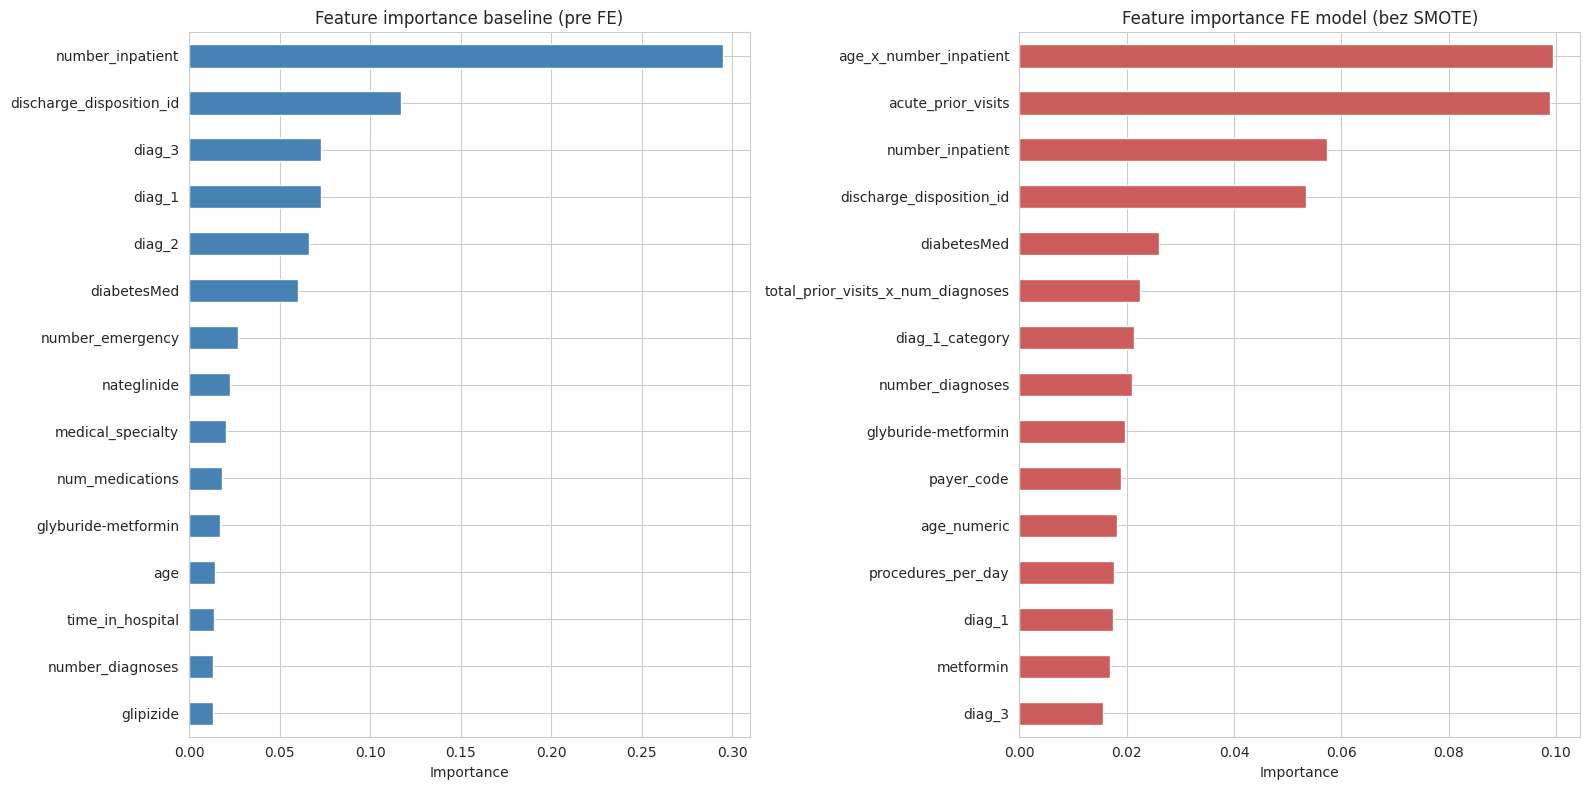

Top 10 baseline:


,0
number_inpatient,0.294773
discharge_disposition_id,0.117214
diag_3,0.072963
diag_1,0.072633
diag_2,0.066355
diabetesMed,0.060396
number_emergency,0.027060
nateglinide,0.022435
medical_specialty,0.020388
num_medications,0.018025



Top 10 FE:


,0
age_x_number_inpatient,0.099503
acute_prior_visits,0.098850
number_inpatient,0.057303
discharge_disposition_id,0.053478
diabetesMed,0.026036
total_prior_visits_x_num_diagnoses,0.022409
diag_1_category,0.021347
number_diagnoses,0.021064
glyburide-metformin,0.019659
payer_code,0.018921


In [32]:
model_baseline_fi = xgb.XGBClassifier(
    **base_params, tree_method='hist', enable_categorical=True,
    eval_metric='aucpr',
    scale_pos_weight=(y_train_base == 0).sum() / (y_train_base == 1).sum(),
    random_state=RANDOM_SEED, n_jobs=-1
)
model_baseline_fi.fit(X_train_base, y_train_base)

model_fe_fi = xgb.XGBClassifier(
    **base_params, tree_method='hist',
    eval_metric='aucpr',
    scale_pos_weight=(y_train_fe == 0).sum() / (y_train_fe == 1).sum(),
    random_state=RANDOM_SEED, n_jobs=-1
)
model_fe_fi.fit(X_train_fe, y_train_fe)

fi_baseline = pd.Series(model_baseline_fi.feature_importances_, index=X_train_base.columns).sort_values(ascending=False)
fi_fe = pd.Series(model_fe_fi.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

fi_baseline.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature importance baseline (pre FE)')
axes[0].set_xlabel('Importance')

fi_fe.head(15).sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Feature importance FE model (bez SMOTE)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('Top 10 baseline:')
display(fi_baseline.head(10))
print('\nTop 10 FE:')
display(fi_fe.head(10))

##AutoML (Ray Tune)


In [33]:
def train_and_validate(config, X=None, y=None, groups=None, splitter=None, use_smote=False):
    pr_auc_scores = []
    for tr_idx, val_idx in splitter.split(X, y, groups=groups):
        X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
        y_tr, y_val = y[tr_idx], y[val_idx]

        if use_smote:
            X_tr, y_tr = SMOTE(random_state=RANDOM_SEED).fit_resample(X_tr, y_tr)

        n_neg, n_pos = (y_tr == 0).sum(), (y_tr == 1).sum()

        model = xgb.XGBClassifier(
            max_depth=config['max_depth'],
            learning_rate=config['learning_rate'],
            subsample=config['subsample'],
            colsample_bytree=config['colsample_bytree'],
            min_child_weight=config['min_child_weight'],
            reg_alpha=config['reg_alpha'],
            reg_lambda=config['reg_lambda'],
            n_estimators=config['n_estimators'],
            scale_pos_weight=n_neg / n_pos,
            tree_method='hist', eval_metric='aucpr',
            random_state=RANDOM_SEED, n_jobs=2
        )
        model.fit(X_tr, y_tr)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        pr_auc_scores.append(average_precision_score(y_val, y_pred_proba))

    tune.report({'pr_auc': float(np.mean(pr_auc_scores))})

search_space = {
    'max_depth': tune.randint(3, 10),
    'learning_rate': tune.loguniform(1e-2, 3e-1),
    'subsample': tune.uniform(0.5, 1.0),
    'colsample_bytree': tune.uniform(0.5, 1.0),
    'min_child_weight': tune.randint(1, 20),
    'reg_alpha': tune.loguniform(1e-3, 10.0),
    'reg_lambda': tune.loguniform(1e-3, 10.0),
    'n_estimators': tune.randint(100, 600),
}

In [34]:
ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False)

trainable = tune.with_parameters(
    train_and_validate,
    X=X_train_fe, y=y_train_fe, groups=groups_train_fe,
    splitter=sgkf, use_smote=use_smote_final
)

scheduler = ASHAScheduler(metric='pr_auc', mode='max', max_t=1, grace_period=1)

analysis = tune.run(
    trainable,
    config=search_space,
    num_samples=30,
    scheduler=scheduler,
    resources_per_trial={'cpu': 2},
    verbose=1,
)

best_config = analysis.get_best_config(metric='pr_auc', mode='max')
best_config

2026-09-14 20:11:01,051	INFO worker.py:2024 -- Started a local Ray instance.


+---------------------------------------------------------------------------+
| Configuration for experiment     train_and_validate_2026-09-14_20-11-06   |
+---------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                    |
| Scheduler                        AsyncHyperBandScheduler                  |
| Number of trials                 30                                       |
+---------------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_and_validate_2026-09-14_20-11-06
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-09-14_20-10-42_595014_643/artifacts/2026-09-14_20-11-06/train_and_validate_2026-09-14_20-11-06/driver_artifacts`

Trial status: 30 PENDING
Current time: 2026-09-14 20:11:12. Total running time: 0s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+--------------------------------

2026-09-14 20:54:11,755	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_and_validate_2026-09-14_20-11-06' in 0.0211s.



Trial train_and_validate_6b6cf_00029 completed after 1 iterations at 2026-09-14 20:54:11. Total running time: 42min 59s
+---------------------------------------------------------+
| Trial train_and_validate_6b6cf_00029 result             |
+---------------------------------------------------------+
| checkpoint_dir_name                                     |
| time_this_iter_s                                57.0109 |
| time_total_s                                    57.0109 |
| training_iteration                                    1 |
| pr_auc                                          0.21487 |
+---------------------------------------------------------+

Trial status: 30 TERMINATED
Current time: 2026-09-14 20:54:11. Total running time: 42min 59s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

{'max_depth': 6,
 'learning_rate': 0.016256670876862694,
 'subsample': 0.8254442364744264,
 'colsample_bytree': 0.5282057895135501,
 'min_child_weight': 12,
 'reg_alpha': 5.678201970293126,
 'reg_lambda': 0.0010071984838809194,
 'n_estimators': 543}

##Finalni model


In [35]:
X_train_final, y_train_final = X_train_fe.copy(), y_train_fe.copy()

if use_smote_final:
    X_train_final, y_train_final = SMOTE(random_state=RANDOM_SEED).fit_resample(X_train_final, y_train_final)

n_neg_final, n_pos_final = (y_train_final == 0).sum(), (y_train_final == 1).sum()

final_model = xgb.XGBClassifier(
    **best_config,
    scale_pos_weight=n_neg_final / n_pos_final,
    tree_method='hist', eval_metric='aucpr',
    random_state=RANDOM_SEED, n_jobs=-1
)
final_model.fit(X_train_final, y_train_final)

y_test_proba = final_model.predict_proba(X_test_fe)[:, 1]
TARGET_RECALL = 0.75

precision_curve_opt, recall_curve_opt, thresholds_opt = precision_recall_curve(y_test_fe, y_test_proba)
valid_idx = np.where(recall_curve_opt[:-1] >= TARGET_RECALL)[0]

if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precision_curve_opt[valid_idx])]
    decision_threshold = thresholds_opt[best_idx]
    print(f"Optimalan prag za recall >= {TARGET_RECALL}: {decision_threshold:.4f}")
    print(f"  -> recall={recall_curve_opt[best_idx]:.4f}, precision={precision_curve_opt[best_idx]:.4f}")
else:
    decision_threshold = 0.5
    print(f"Nije pronadjen prag koji dostize recall={TARGET_RECALL}, koristi se 0.5")

y_test_pred = (y_test_proba >= decision_threshold).astype(int)


Optimalan prag za recall >= 0.75: 0.4189
  -> recall=0.7500, precision=0.1539


##Offline evaluacija


In [36]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train_fe, y_train_fe)
y_test_proba_dummy = dummy.predict_proba(X_test_fe)[:, 1]
y_test_pred_dummy = dummy.predict(X_test_fe)

tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test_fe, y_test_pred_dummy).ravel()
tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_test_fe, y_test_pred).ravel()

results_table = pd.DataFrame({
    'baseline (dummy)': {
        'roc_auc': roc_auc_score(y_test_fe, y_test_proba_dummy),
        'pr_auc': average_precision_score(y_test_fe, y_test_proba_dummy),
        'recall': recall_score(y_test_fe, y_test_pred_dummy),
        'precision': precision_score(y_test_fe, y_test_pred_dummy),
        'f1': f1_score(y_test_fe, y_test_pred_dummy),
        'specificity': tn_d / (tn_d + fp_d),
        'balanced_accuracy': balanced_accuracy_score(y_test_fe, y_test_pred_dummy),
    },
    'finalni model (test)': {
        'roc_auc': roc_auc_score(y_test_fe, y_test_proba),
        'pr_auc': average_precision_score(y_test_fe, y_test_proba),
        'recall': recall_score(y_test_fe, y_test_pred),
        'precision': precision_score(y_test_fe, y_test_pred),
        'f1': f1_score(y_test_fe, y_test_pred),
        'specificity': tn_f / (tn_f + fp_f),
        'balanced_accuracy': balanced_accuracy_score(y_test_fe, y_test_pred),
    },
})
results_table

,baseline (dummy),finalni model (test)
roc_auc,0.493972,0.675708
pr_auc,0.112818,0.237975
recall,0.102890,0.750000
precision,0.103206,0.153908
f1,0.103048,0.255405
specificity,0.885055,0.469913
balanced_accuracy,0.493972,0.609956


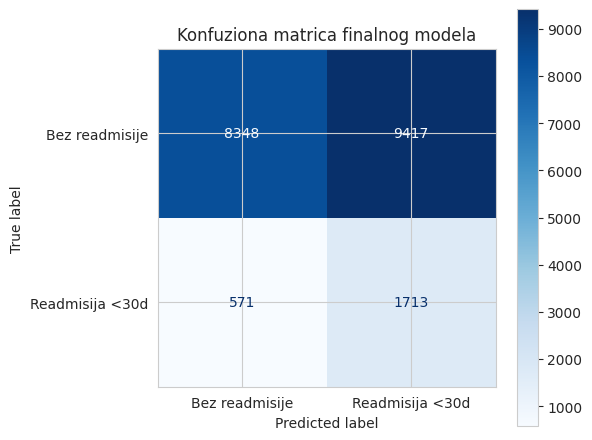

In [37]:
cm = confusion_matrix(y_test_fe, y_test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bez readmisije', 'Readmisija <30d']).plot(
    ax=ax, cmap='Blues', values_format='d'
)
ax.set_title('Konfuziona matrica finalnog modela')
plt.tight_layout()
plt.show()

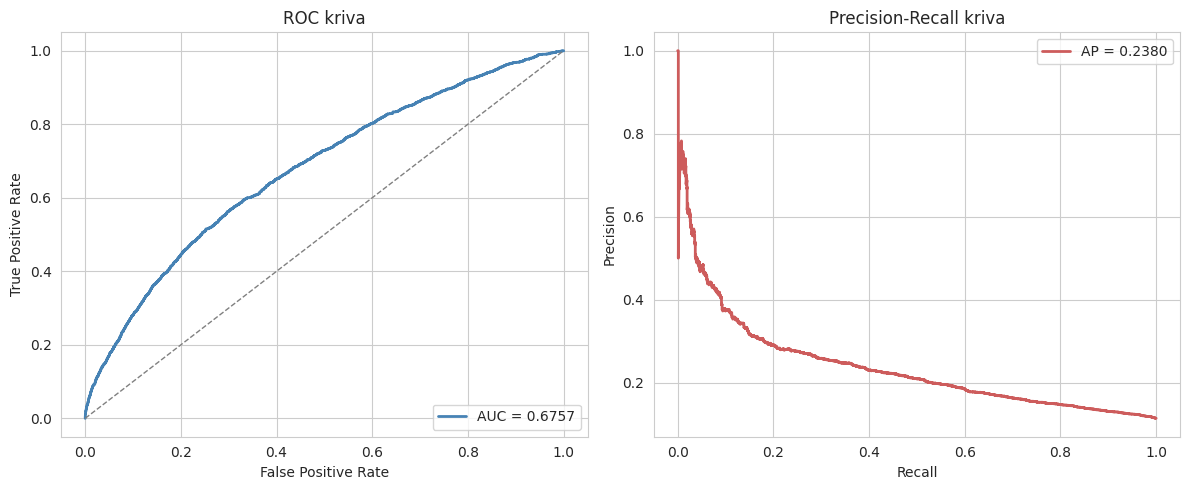

In [38]:
fpr, tpr, _ = roc_curve(y_test_fe, y_test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_fe, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc_score(y_test_fe, y_test_proba):.4f}')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC kriva')
axes[0].legend(loc='lower right')

axes[1].plot(recall_curve, precision_curve, color='indianred', lw=2,
             label=f'AP = {average_precision_score(y_test_fe, y_test_proba):.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall kriva')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()